<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/2dcnn_trad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 16 bit

In [ ]:
import os
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/1bit_speech/preprocessed/preprocessed_16bit.zip"
extract_path = "/content/drive/MyDrive/1bit_speech/preprocessed"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
DATA_PATH = "/content/drive/MyDrive/1bit_speech/preprocessed"

X_train = np.load(os.path.join(DATA_PATH,"X_train.npy"))
X_val   = np.load(os.path.join(DATA_PATH,"X_val.npy"))
X_test  = np.load(os.path.join(DATA_PATH,"X_test.npy"))

y_train = np.load(os.path.join(DATA_PATH,"y_train.npy"))
y_val   = np.load(os.path.join(DATA_PATH,"y_val.npy"))
y_test  = np.load(os.path.join(DATA_PATH,"y_test.npy"))

In [ ]:
print("Train :",X_train.shape)
print("Val   :",X_val.shape)
print("Test  :",X_test.shape)

print()

print(np.unique(y_train))

print()

print(X_train.dtype)

Train : (9600, 16000, 1)
Val   : (1200, 16000, 1)
Test  : (1200, 16000, 1)

[0 1 2 3]

float32


In [ ]:
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train,y_train)
)

train_ds = train_ds.shuffle(
    2000,
    seed=SEED
).batch(
    BATCH_SIZE
).prefetch(
    AUTOTUNE
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val,y_val)
)

val_ds = val_ds.batch(
    BATCH_SIZE
).prefetch(
    AUTOTUNE
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test,y_test)
)

test_ds = test_ds.batch(
    BATCH_SIZE
).prefetch(
    AUTOTUNE
)

In [ ]:
class LogMelLayer(tf.keras.layers.Layer):

    def __init__(
        self,
        sample_rate=16000,
        frame_length=400,
        frame_step=160,
        fft_length=512,
        n_mels=40,
        fmin=20,
        fmax=4000
    ):

        super().__init__()

        self.sample_rate = sample_rate
        self.frame_length = frame_length
        self.frame_step = frame_step
        self.fft_length = fft_length
        self.n_mels = n_mels
        self.fmin = fmin
        self.fmax = fmax

    def call(self,x):

        x = tf.squeeze(x,-1)

        stft = tf.signal.stft(
            x,
            frame_length=self.frame_length,
            frame_step=self.frame_step,
            fft_length=self.fft_length
        )

        spectrogram = tf.abs(stft)

        mel_matrix = tf.signal.linear_to_mel_weight_matrix(
            self.n_mels,
            spectrogram.shape[-1],
            self.sample_rate,
            self.fmin,
            self.fmax
        )

        mel = tf.tensordot(
            spectrogram,
            mel_matrix,
            1
        )

        mel.set_shape(
            spectrogram.shape[:-1].concatenate(
                mel_matrix.shape[-1:]
            )
        )

        logmel = tf.math.log(
            mel + 1e-6
        )

        return tf.expand_dims(
            logmel,
            -1
        )

In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal

WEIGHT_DECAY = 1e-4

def build_cnn_baseline(input_shape=(16000,1), num_classes=4):

    inputs = Input(shape=input_shape, name="waveform")

    # ==========================================================
    # Feature Extraction
    # ==========================================================
    x = LogMelLayer()(inputs)

    # ==========================================================
    # Block 1
    # ==========================================================
    x = layers.Conv2D(
        filters=64,
        kernel_size=(20,8),
        padding="same",
        use_bias=False,
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=(2,2),
        strides=(2,2)
    )(x)

    # ==========================================================
    # Block 2
    # ==========================================================
    x = layers.Conv2D(
        filters=64,
        kernel_size=(10,4),
        padding="same",
        use_bias=False,
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(
        pool_size=(2,2),
        strides=(2,2)
    )(x)

    # ==========================================================
    # Block 3
    # ==========================================================
    x = layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding="same",
        use_bias=False,
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # ==========================================================
    # Bottleneck
    # ==========================================================
    x = layers.Conv2D(
        filters=128,
        kernel_size=(1,1),
        padding="same",
        use_bias=False,
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # ==========================================================
    # Classification Head
    # ==========================================================
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(WEIGHT_DECAY)
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions"
    )(x)

    model = Model(
        inputs,
        outputs,
        name="CNN_Baseline"
    )

    return model

In [ ]:
model = build_cnn_baseline()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

model.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)           │ (None, 16000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_mel_layer_1 (LogMelLayer)   │ (None, 98, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 98, 40, 64)     │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 98, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 98, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 20, 64)     │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 49, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 49, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 10, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 24, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 10, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 24, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 245,444 (958.77 KB)

 Trainable params: 244,804 (956.27 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "cnn_baseline.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

]

In [ ]:
LEARNING_RATE = 3e-4

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

In [ ]:
import os

SAVE_PATH = "cnn_baseline.keras"

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

]

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64

print("Epochs :", EPOCHS)
print("Batch Size :", BATCH_SIZE)
print("Learning Rate :", LEARNING_RATE)

Epochs : 50
Batch Size : 64
Learning Rate : 0.0003


In [ ]:
start_time = time.time()

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time/60:.2f} minutes")

Epoch 1/50
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6689 - loss: 0.8906
Epoch 1: val_accuracy improved from None to 0.73583, saving model to cnn_baseline.keras

Epoch 1: finished saving model to cnn_baseline.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.7596 - loss: 0.7050 - val_accuracy: 0.7358 - val_loss: 0.7316 - learning_rate: 3.0000e-04
Epoch 2/50
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8642 - loss: 0.4813
Epoch 2: val_accuracy improved from 0.73583 to 0.86583, saving model to cnn_baseline.keras

Epoch 2: finished saving model to cnn_baseline.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8748 - loss: 0.4488 - val_accuracy: 0.8658 - val_loss: 0.4618 - learning_rate: 3.0000e-04
Epoch 3/50
297/300 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8992 - loss: 0.3941
Epoch 3: val_accuracy did not improve from 0.86583
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9049 - loss: 0.3787 - val_accuracy: 0.8442 - val_los

In [ ]:
test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9792 - loss: 0.1521

Test Accuracy : 0.9792
Test Loss     : 0.1521


In [ ]:
import numpy as np

y_prob = model.predict(test_ds, verbose=1)

y_pred = np.argmax(y_prob, axis=1)

y_true = np.concatenate(
    [y.numpy() for _, y in test_ds]
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

roc_auc = roc_auc_score(
    tf.keras.utils.to_categorical(y_true,4),
    y_prob,
    multi_class="ovr"
)

print("="*50)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)
print("="*50)

Accuracy : 0.9791666666666666
Precision: 0.979424135716137
Recall   : 0.9791666666666667
F1 Score : 0.9790968648001582
ROC AUC  : 0.999137962962963


In [ ]:
from sklearn.metrics import classification_report

class_names = [
    "Command",
    "Conversation",
    "Numeric",
    "Read"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     Command     0.9644    0.9933    0.9787       300
Conversation     0.9706    0.9900    0.9802       300
     Numeric     0.9966    0.9900    0.9933       300
        Read     0.9861    0.9433    0.9642       300

    accuracy                         0.9792      1200
   macro avg     0.9794    0.9792    0.9791      1200
weighted avg     0.9794    0.9792    0.9791      1200



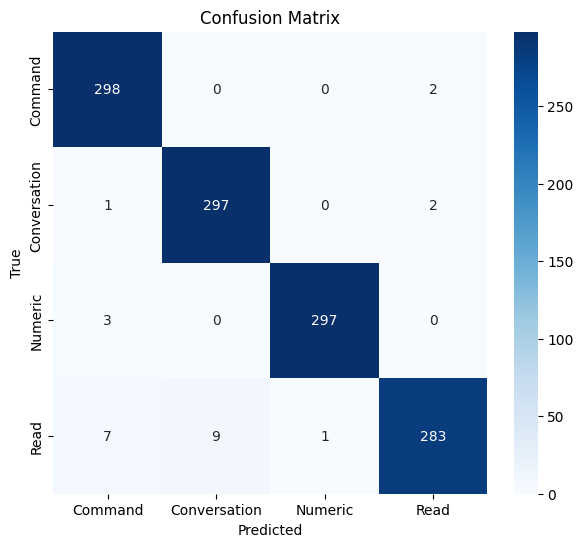

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

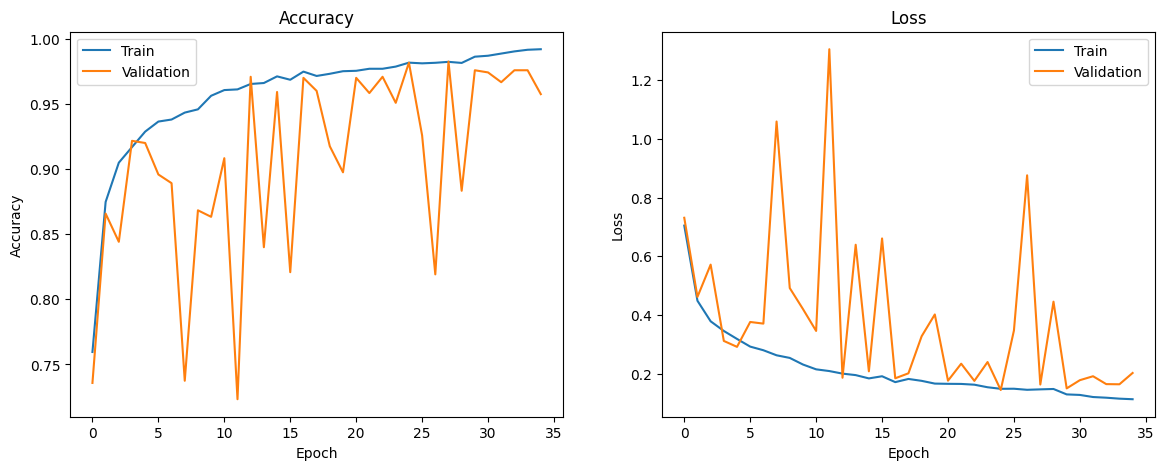

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
print("="*60)

print("Final Training Accuracy :", history.history["accuracy"][-1])
print("Final Validation Accuracy :", history.history["val_accuracy"][-1])

print()

print("Final Training Loss :", history.history["loss"][-1])
print("Final Validation Loss :", history.history["val_loss"][-1])

print()

print("Best Validation Accuracy :", max(history.history["val_accuracy"]))

print()

print(f"Training Time : {training_time/60:.2f} minutes")

print()

print("Total Parameters :", model.count_params())

print("="*60)

Final Training Accuracy : 0.99197918176651
Final Validation Accuracy : 0.9574999809265137

Final Training Loss : 0.1130555123090744
Final Validation Loss : 0.2025231420993805

Best Validation Accuracy : 0.9825000166893005

Training Time : 3.04 minutes

Total Parameters : 245444


In [ ]:
results = {
    "Architecture": "CNN_Baseline",
    "Train Accuracy": history.history["accuracy"][-1],
    "Validation Accuracy": history.history["val_accuracy"][-1],
    "Best Validation Accuracy": max(history.history["val_accuracy"]),
    "Test Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC AUC": roc_auc,
    "Parameters": model.count_params(),
    "Training Time (min)": training_time / 60
}

import pandas as pd

results_df = pd.DataFrame([results])
results_df

,Architecture,Train Accuracy,Validation Accuracy,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,Parameters,Training Time (min)
0,CNN_Baseline,0.991979,0.9575,0.9825,0.979167,0.979424,0.979167,0.979097,0.999138,245444,3.039475


# 1bit

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/1bit_speech/preprocessed/preprocessed_1bit.zip"
extract_path = "/content/preprocessed_1bit"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed")

Extraction Completed


In [ ]:
for f in sorted(os.listdir(extract_path)):
    print(f)

X_1bit_test.npy
X_1bit_train.npy
X_1bit_val.npy
y_1bit_test.npy
y_1bit_train.npy
y_1bit_val.npy


In [ ]:
X_train = np.load(os.path.join(extract_path, "X_1bit_train.npy"))
X_val   = np.load(os.path.join(extract_path, "X_1bit_val.npy"))
X_test  = np.load(os.path.join(extract_path, "X_1bit_test.npy"))

y_train = np.load(os.path.join(extract_path, "y_1bit_train.npy"))
y_val   = np.load(os.path.join(extract_path, "y_1bit_val.npy"))
y_test  = np.load(os.path.join(extract_path, "y_1bit_test.npy"))

In [ ]:
X_train = np.squeeze(X_train)
X_val   = np.squeeze(X_val)
X_test  = np.squeeze(X_test)

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

In [ ]:
print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

print()

print("dtype :", X_train.dtype)

print()

print("Min :", X_train.min())
print("Max :", X_train.max())

print()

print("Unique values :", np.unique(X_train))

Train : (9600, 16000, 1)
Val   : (1200, 16000, 1)
Test  : (1200, 16000, 1)

dtype : float32

Min : -1.0
Max : 1.0

Unique values : [-1.  1.]


In [ ]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model = build_cnn_baseline(
    input_shape=(16000,1),
    num_classes=4
)

model.summary()

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)           │ (None, 16000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_mel_layer (LogMelLayer)     │ (None, 98, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 40, 64)     │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 98, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 49, 20, 64)     │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 49, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 49, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 10, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 10, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 245,444 (958.77 KB)

 Trainable params: 244,804 (956.27 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "cnn_1bit.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

]

In [ ]:
EPOCHS = 50

start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start

print(f"\nTraining Time : {training_time/60:.2f} minutes")

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4987 - loss: 1.1559
Epoch 1: val_accuracy improved from None to 0.58667, saving model to cnn_1bit.keras

Epoch 1: finished saving model to cnn_1bit.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5857 - loss: 1.0130 - val_accuracy: 0.5867 - val_loss: 0.9823 - learning_rate: 3.0000e-04
Epoch 2/50
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6883 - loss: 0.8235
Epoch 2: val_accuracy did not improve from 0.58667
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7111 - loss: 0.7848 - val_accuracy: 0.4800 - val_loss: 1.9882 - learning_rate: 3.0000e-04
Epoch 3/50
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7608 - loss: 0.7050
Epoch 3: val_accuracy did not improve from 0.58667
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7702 - loss: 0.6829 - val_accuracy: 0.5025 - val_loss: 1.2204 - learning_rate: 3.0000e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy:

In [ ]:
test_loss, test_acc = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8942 - loss: 0.3576

Test Accuracy : 0.8942
Test Loss     : 0.3576


In [ ]:
import numpy as np

y_prob = model.predict(test_ds, verbose=1)

y_pred = np.argmax(y_prob, axis=1)

y_true = np.concatenate(
    [y.numpy() for _, y in test_ds]
)


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

roc_auc = roc_auc_score(
    tf.keras.utils.to_categorical(y_true,4),
    y_prob,
    multi_class="ovr"
)

print("="*50)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)
print("="*50)


Accuracy : 0.8941666666666667
Precision: 0.8946081146271092
Recall   : 0.8941666666666667
F1 Score : 0.894178373705828
ROC AUC  : 0.9834611111111111


In [ ]:

from sklearn.metrics import classification_report

class_names = [
    "Command",
    "Conversation",
    "Numeric",
    "Read"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     Command     0.9207    0.8900    0.9051       300
Conversation     0.8508    0.8933    0.8715       300
     Numeric     0.9900    0.9900    0.9900       300
        Read     0.8169    0.8033    0.8101       300

    accuracy                         0.8942      1200
   macro avg     0.8946    0.8942    0.8942      1200
weighted avg     0.8946    0.8942    0.8942      1200



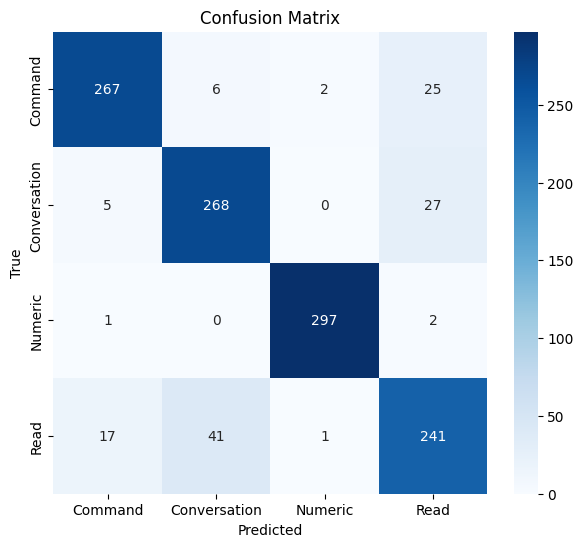

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()



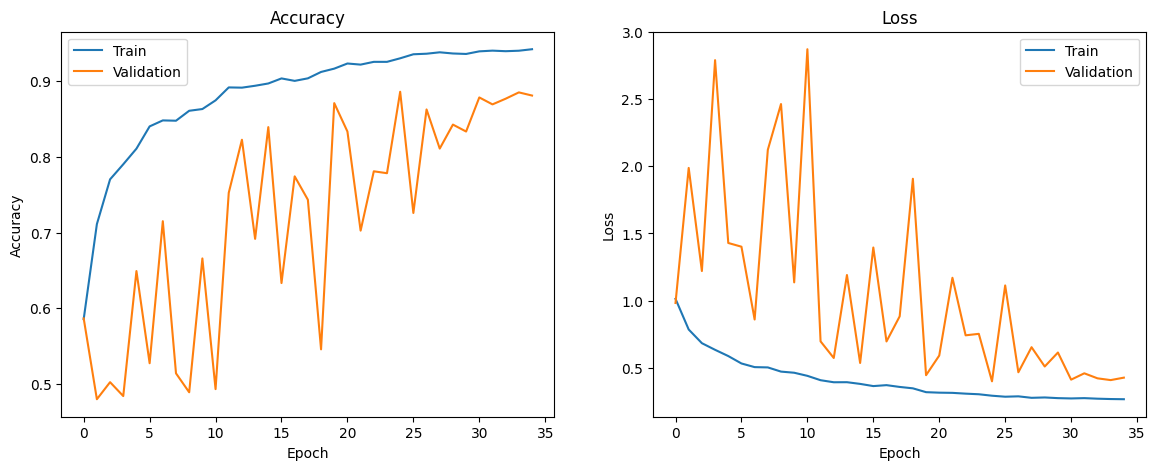

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
print("="*60)

print("Final Training Accuracy :", history.history["accuracy"][-1])
print("Final Validation Accuracy :", history.history["val_accuracy"][-1])

print()

print("Final Training Loss :", history.history["loss"][-1])
print("Final Validation Loss :", history.history["val_loss"][-1])

print()

print("Best Validation Accuracy :", max(history.history["val_accuracy"]))

print()

print(f"Training Time : {training_time/60:.2f} minutes")

print()

print("Total Parameters :", model.count_params())

print("="*60)



Final Training Accuracy : 0.941979169845581
Final Validation Accuracy : 0.8808333277702332

Final Training Loss : 0.2655065059661865
Final Validation Loss : 0.4262271821498871

Best Validation Accuracy : 0.8858333230018616

Training Time : 2.76 minutes

Total Parameters : 245444


In [ ]:
results = {
    "Architecture": "CNN_Baseline",
    "Train Accuracy": history.history["accuracy"][-1],
    "Validation Accuracy": history.history["val_accuracy"][-1],
    "Best Validation Accuracy": max(history.history["val_accuracy"]),
    "Test Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC AUC": roc_auc,
    "Parameters": model.count_params(),
    "Training Time (min)": training_time / 60
}

import pandas as pd

results_df = pd.DataFrame([results])
results_df

,Architecture,Train Accuracy,Validation Accuracy,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,Parameters,Training Time (min)
0,CNN_Baseline,0.941979,0.880833,0.885833,0.894167,0.894608,0.894167,0.894178,0.983461,245444,2.758787
